In [1]:
import re
import numpy as np
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12

def cfc(data, cutoff_frequency=1000, sampling_rate=10000):
    filter_order = 4
    nyquist_frequency = 0.5 * sampling_rate
    normalized_cutoff = cutoff_frequency / nyquist_frequency
    b, a = signal.butter(filter_order, normalized_cutoff, btype='low', analog=False)
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

def hic15(df, time_col='Time', res_col='Resultant'):
    t_sec = df[time_col].values/1000
    a_g = df[res_col].values*(1000.0 / 9.80665)
    A = cumulative_trapezoid(a_g, t_sec, initial=0)
    
    max_hic = 0.0
    best_t1 = 0.0
    best_t2 = 0.0
    n = len(t_sec)
    
    for i in range(n):
        for j in range(i + 1, n):
            dt = t_sec[j] - t_sec[i]
            if dt > 0.015:  #change here for different time interval
                break
            if dt > 0:
                integral_val = A[j] - A[i]
                avg_accel = integral_val / dt
                hic_val = dt * (avg_accel ** 2.5)
                if hic_val > max_hic:
                    max_hic = hic_val
                    best_t1 = t_sec[i]
                    best_t2 = t_sec[j]
                    
    # return {
    #     'HIC15': max_hic,
    #     't1': best_t1 * 1000,
    #     't2': best_t2 * 1000,
    #     't2-t1': (best_t2 - best_t1) * 1000
    # }
    return max_hic

HIC (Experiment) = 1074 ± 59
HIC (Simulation) =  945.0430787338391


C:\Users\GSK\AppData\Local\Temp\ipykernel_38408\4204549978.py:37: RuntimeWarning: invalid value encountered in scalar power
  hic_val = dt * (avg_accel ** 2.5)


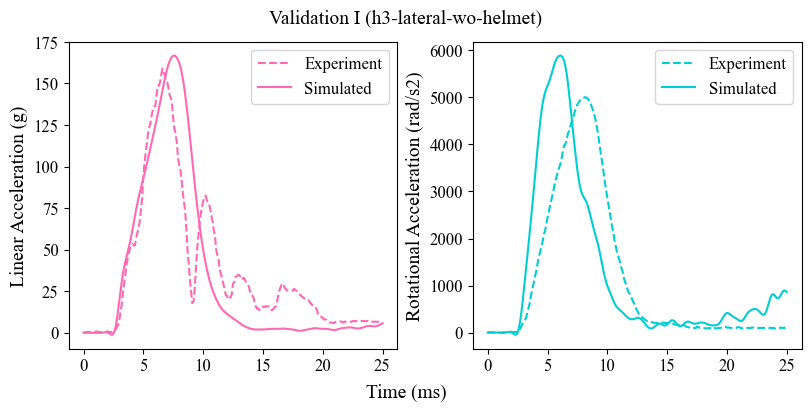

In [2]:
num_pattern = r"[+-]?\d+\.\d+E[+-]?\d+"
time_pattern = r"at time\s*([+-]?\d+\.\d+E[+-]?\d+)"

accels = []
rot_accels = []
current_time = None

with open("nodout") as f:
    nodout = f.readlines()

for i, step in enumerate(nodout):
    time_match = re.search(time_pattern, step)
    if time_match:
        current_time = float(time_match.group(1))
    if "x-disp" in step:
        data_line = nodout[i + 1]
        nums = re.findall(num_pattern, data_line)
        if len(nums) >= 9 and current_time is not None:
            nums = list(map(float, nums))
            accels.append((current_time, *nums[6:9]))
    elif "x-rot" in step:
        data_line = nodout[i + 1]
        nums = re.findall(num_pattern, data_line)
        if len(nums) >= 9 and current_time is not None:
            nums = list(map(float, nums))
            rot_accels.append((current_time, *nums[6:9]))

accel_df = pd.DataFrame(accels, columns=["Time", "X", "Y", "Z"])
rot_accel_df = pd.DataFrame(rot_accels, columns=["Time", "X", "Y", "Z"])
accel_df["Resultant"] = cfc(np.linalg.norm(accel_df[["X", "Y", "Z"]].values, axis=1))
rot_accel_df["Resultant"] = cfc(np.linalg.norm(rot_accel_df[["X", "Y", "Z"]].values, axis=1))

time = accel_df["Time"]
lit_l = pd.read_csv("linear.csv", header=None)
lit_r = pd.read_csv("rotational.csv", header=None)

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=[8, 4])
ax[0].plot(lit_l[0], lit_l[1]/50, color="hotpink", label="Experiment", linestyle="--")
ax[1].plot(
    lit_r[0], lit_r[1], color="darkturquoise", label="Experiment", linestyle="--"
)

ax[0].plot(
    time, accel_df["Resultant"] * (1000.0 / 9.80665), color="hotpink", label="Simulated"
)
ax[1].plot(
    time,
    rot_accel_df["Resultant"] * 1000000,
    color="darkturquoise",
    label="Simulated",
)

print('HIC (Experiment) = 1074 ± 59')
print('HIC (Simulation) = ', hic15(accel_df))
ax[0].legend()
ax[1].legend()
ax[0].set_ylabel("Linear Acceleration (g)", fontsize=14)
ax[1].set_ylabel("Rotational Acceleration (rad/s2)", fontsize=14)
fig.supxlabel("Time (ms)", fontsize=14)
plt.suptitle("Validation I (h3-lateral-wo-helmet)", fontsize=14);